# Сравнение обучения нейронной сети с квадратичной функцией потерь и перекрестной энтропией

**Авторы:** Ляхов Ярослав, Суворов Степан  
**Университет:** Университет Иннополис

## Цель работы

Рассмотреть обучение нейронной сети для бинарной классификации. Сравнить работу метода обратного распространения ошибки при двух функциях потерь:

- квадратичная функция потерь, то есть MSE;
- перекрестная энтропия, то есть Binary Cross-Entropy.

Сравнение проводится на одной архитектуре, одном наборе данных, одинаковой инициализации и одинаковом оптимизаторе. Так видно влияние функции потерь на градиенты, скорость обучения и качество классификации.

## Теоретическая часть

Пусть нейронная сеть для бинарной классификации выдает логит $z$. Вероятность класса `1` получается через sigmoid:

$$
p = \sigma(z) = \frac{1}{1 + e^{-z}}.
$$

При обратном распространении ошибки градиент параметров получается по цепному правилу:

$$
\frac{\partial L}{\partial w} =
\frac{\partial L}{\partial z}
\frac{\partial z}{\partial w}.
$$

Значит, функция потерь задает величину сигнала, который идет назад по сети.

### Перекрестная энтропия

Для бинарной классификации:

$$
L_{BCE}= -y\log p -(1-y)\log(1-p).
$$

Если совместить BCE с sigmoid, то градиент по логиту имеет простой вид:

$$
\frac{\partial L_{BCE}}{\partial z}=p-y.
$$

### Квадратичная функция потерь

Если использовать MSE для вероятности:

$$
L_{MSE}=(p-y)^2,
$$

то градиент по логиту:

$$
\frac{\partial L_{MSE}}{\partial z}=2(p-y)p(1-p).
$$

Главное отличие: у MSE появляется множитель $p(1-p)$. Когда sigmoid насыщается, $p$ близко к 0 или 1. Тогда этот множитель становится малым. Поэтому MSE может давать слабый градиент даже при сильной ошибке.

### Почему дифференцируем loss по логиту `z`

Функции потерь ниже записаны через вероятность `p`, но эта вероятность не является независимой переменной. Она получается из логита сети:

$$
p = \sigma(z).
$$

То есть на самом деле loss зависит от `z` не напрямую, а через sigmoid:

$$
L = L(p, y) = L(\sigma(z), y).
$$

Поэтому при обратном распространении ошибки используется цепное правило:

$$
\frac{\partial L}{\partial z}
=
\frac{\partial L}{\partial p}
\cdot
\frac{\partial p}{\partial z}.
$$

Например, для MSE:

$$
L_{MSE} = (p-y)^2,
$$

поэтому:

$$
\frac{\partial L_{MSE}}{\partial p} = 2(p-y),
$$

а для sigmoid:

$$
\frac{\partial p}{\partial z} = p(1-p).
$$

В итоге:

$$
\frac{\partial L_{MSE}}{\partial z}
=
2(p-y)p(1-p).
$$

Именно поэтому в формулах появляется производная по `z`: логит `z` скрыт внутри вероятности `p`.

In [28]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, f1_score, log_loss, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
print(f"torch: {torch.__version__}")

device: cpu
torch: 2.12.0+cpu


## 1. Сравнение градиентов по логиту

Сначала сравним не полное обучение, а только сигнал $\partial L / \partial z$, который loss-функция отправляет назад в сеть.

Рассмотрим объект истинного класса $y=1$. Если логит $z$ сильно отрицательный, то модель уверенно ошибается: вероятность $p$ близка к 0.

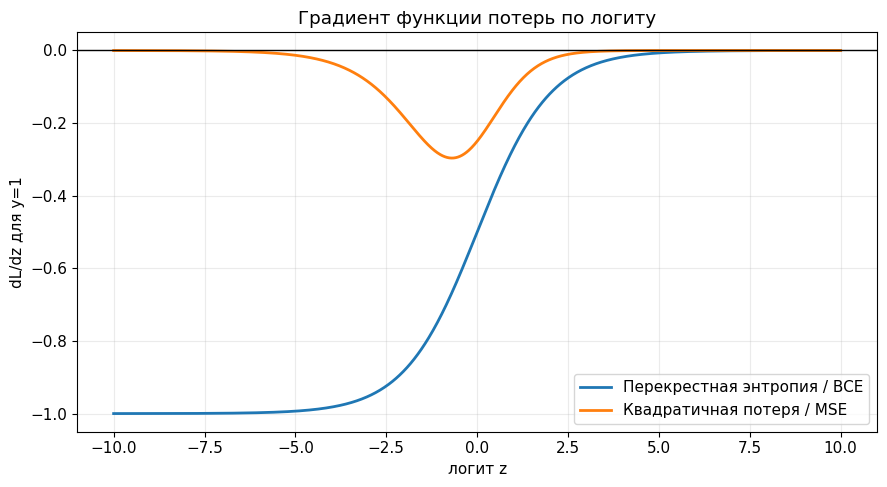

In [29]:
z = torch.linspace(-10, 10, 1000)
p = torch.sigmoid(z)
y = torch.ones_like(p)

grad_bce = p - y
grad_mse = 2 * (p - y) * p * (1 - p)

plt.figure(figsize=(9, 5))
plt.plot(z, grad_bce, label="Перекрестная энтропия / BCE", linewidth=2)
plt.plot(z, grad_mse, label="Квадратичная потеря / MSE", linewidth=2)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("логит z")
plt.ylabel("dL/dz для y=1")
plt.title("Градиент функции потерь по логиту")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/gradient_bce_vs_mse.png", dpi=160)
plt.show()

На графике видно, что при уверенной ошибке $z \ll 0$:

- у BCE градиент близок к `-1`, поэтому сеть получает сильный сигнал для исправления ошибки;
- у MSE градиент близок к `0`, потому что sigmoid насыщена и множитель $p(1-p)$ почти нулевой.

Это объясняет, почему для классификации перекрёстная энтропия обычно обучает сеть быстрее, чем MSE.

## 2. Постановка эксперимента

Используем синтетическую задачу бинарной классификации `make_moons`. Она нелинейно разделима. Поэтому для нее нужна небольшая нейронная сеть, а не просто линейная модель.

Условия сравнения:

- одинаковая обучающая и тестовая выборки;
- одинаковая архитектура MLP;
- одинаковая начальная инициализация весов;
- одинаковый оптимизатор SGD с momentum;
- различается только функция потерь.

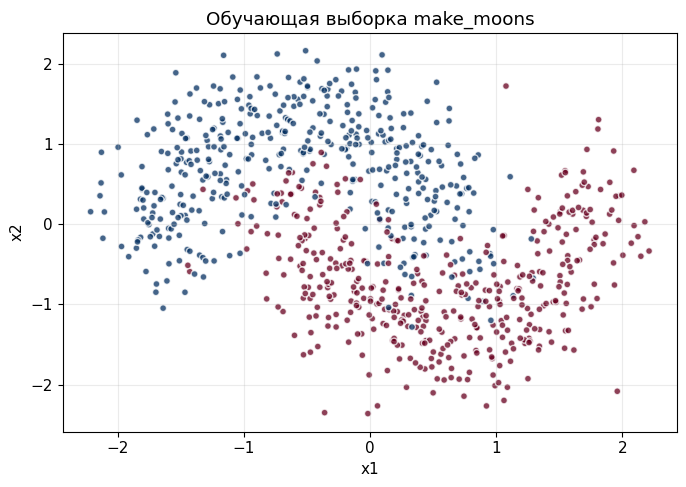

In [30]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=SEED)
X = StandardScaler().fit_transform(X).astype(np.float32)
y = y.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

X_train_t = torch.tensor(X_train, device=device)
y_train_t = torch.tensor(y_train, device=device)
X_test_t = torch.tensor(X_test, device=device)
y_test_t = torch.tensor(y_test, device=device)

plt.figure(figsize=(7, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.ravel(), cmap="RdBu_r", s=24, alpha=0.75, edgecolor="white")
plt.title("Обучающая выборка make_moons")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/dataset_make_moons.png", dpi=160)
plt.show()

In [31]:
class BinaryMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)


def loss_function(name, logits, targets):
    if name == "BCE":
        return F.binary_cross_entropy_with_logits(logits, targets)
    if name == "MSE":
        probs = torch.sigmoid(logits)
        return F.mse_loss(probs, targets)
    raise ValueError(name)


def evaluate(model, X_eval_t=None, y_eval=None):
    if X_eval_t is None:
        X_eval_t = X_test_t
    if y_eval is None:
        y_eval = y_test

    model.eval()
    with torch.no_grad():
        logits = model(X_eval_t)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()

    pred = (probs >= 0.5).astype(int)
    true = y_eval.ravel().astype(int)

    return {
        "accuracy": accuracy_score(true, pred),
        "f1": f1_score(true, pred),
        "log_loss": log_loss(true, np.clip(probs, 1e-7, 1 - 1e-7)),
        "brier_score": mean_squared_error(true, probs),
    }


def train(loss_name, epochs=350, lr=0.05, seed=SEED, track_every=5):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = BinaryMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train_t)
        loss = loss_function(loss_name, logits, y_train_t)
        loss.backward()

        first_layer_grad = model.net[0].weight.grad.detach().norm().item()
        all_grad = torch.sqrt(sum(
            (param.grad.detach() ** 2).sum()
            for param in model.parameters()
            if param.grad is not None
        )).item()

        with torch.no_grad():
            probs_train = torch.sigmoid(logits)
            mean_sigmoid_slope = (probs_train * (1 - probs_train)).mean().item()
            mean_abs_logit = logits.abs().mean().item()

        optimizer.step()

        if epoch % track_every == 0 or epoch == epochs - 1:
            history.append({
                "epoch": epoch,
                "train_loss": loss.item(),
                "grad_norm_first_layer": first_layer_grad,
                "grad_norm_all": all_grad,
                "mean_p_one_minus_p": mean_sigmoid_slope,
                "mean_abs_logit": mean_abs_logit,
                **evaluate(model),
            })

    return model, pd.DataFrame(history)


models = {}
histories = {}
results = {}

for loss_name in ["BCE", "MSE"]:
    model, hist = train(loss_name)
    models[loss_name] = model
    histories[loss_name] = hist
    results[loss_name] = evaluate(model)

pd.DataFrame(results).T

,accuracy,f1,log_loss,brier_score
BCE,0.944444,0.943503,0.149560,0.042632
MSE,0.891667,0.888889,0.296625,0.088968


## 3. Графики обучения

Ниже показаны:

- значение оптимизируемой функции потерь на обучении;
- accuracy на тестовой выборке;
- F1-score на тестовой выборке;
- норма градиента первого слоя.

Градиент первого слоя полезен как индикатор того, насколько сильный сигнал доходит в ранние параметры сети.

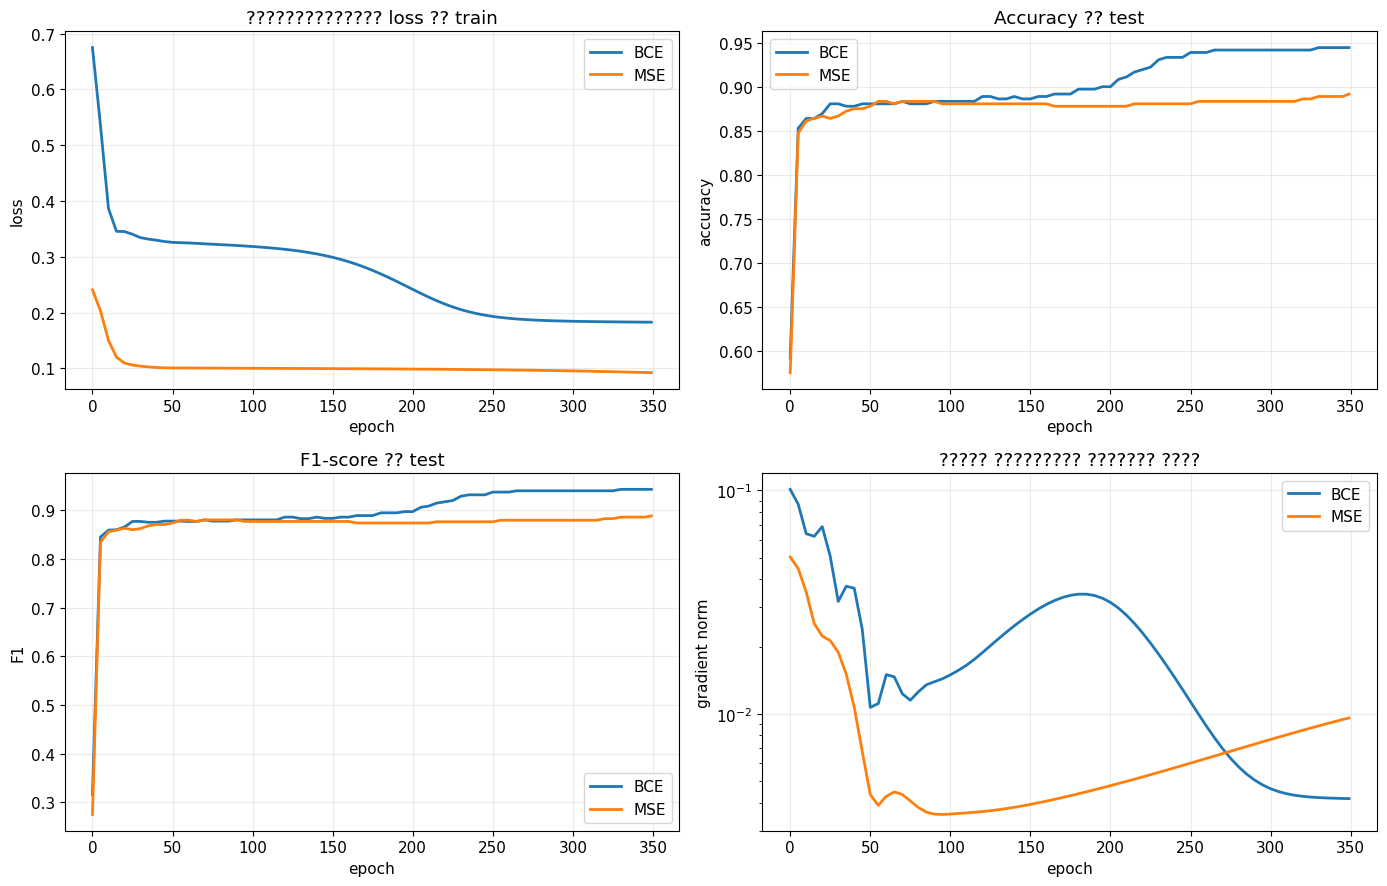

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for loss_name, hist in histories.items():
    axes[0].plot(hist["epoch"], hist["train_loss"], label=loss_name, linewidth=2)
    axes[1].plot(hist["epoch"], hist["accuracy"], label=loss_name, linewidth=2)
    axes[2].plot(hist["epoch"], hist["f1"], label=loss_name, linewidth=2)
    axes[3].plot(hist["epoch"], hist["grad_norm_first_layer"], label=loss_name, linewidth=2)

axes[0].set_title("Оптимизируемый loss на train")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")

axes[1].set_title("Accuracy на test")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")

axes[2].set_title("F1-score на test")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("F1")

axes[3].set_title("Норма градиента первого слоя")
axes[3].set_xlabel("epoch")
axes[3].set_ylabel("gradient norm")
axes[3].set_yscale("log")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/training_bce_vs_mse.png", dpi=160)
plt.show()

### Динамика насыщения sigmoid и скорость достижения порога

Для MSE градиент по логиту содержит множитель $p(1-p)$. Поэтому важно посмотреть не только статическую формулу, но и то, как этот множитель ведет себя во время обучения. Чем меньше среднее $p(1-p)$, тем сильнее sigmoid находится в насыщении и тем слабее сигнал MSE по логиту.

,epoch_to_accuracy_0.90,final_accuracy,final_f1,final_mean_p_one_minus_p
BCE,195.0,0.944444,0.943503,0.056561
MSE,NaN,0.891667,0.888889,0.108099


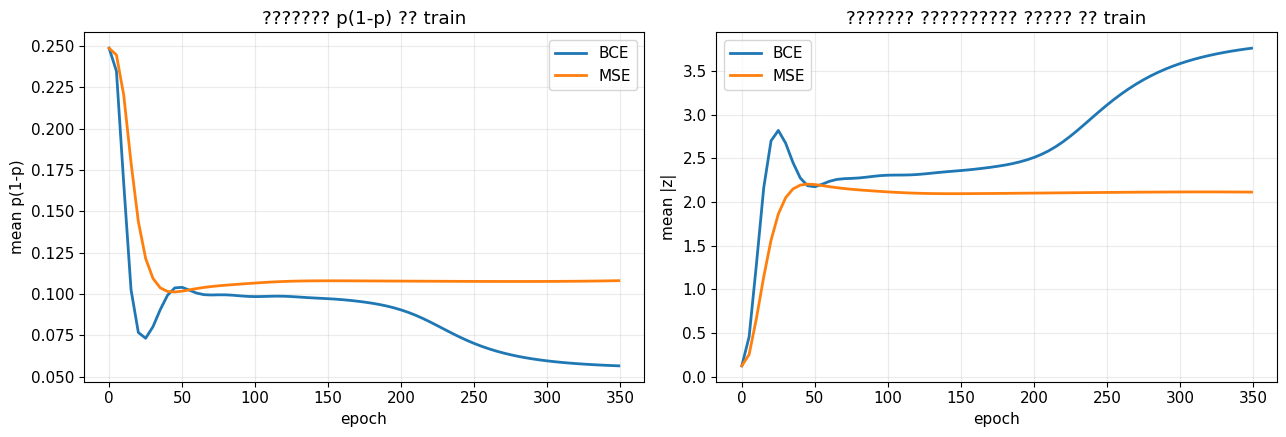

In [33]:
def first_epoch_at(hist, metric="accuracy", threshold=0.90):
    reached = hist.loc[hist[metric] >= threshold, "epoch"]
    return np.nan if reached.empty else int(reached.iloc[0])

convergence = pd.DataFrame({
    loss_name: {
        "epoch_to_accuracy_0.90": first_epoch_at(hist),
        "final_accuracy": hist["accuracy"].iloc[-1],
        "final_f1": hist["f1"].iloc[-1],
        "final_mean_p_one_minus_p": hist["mean_p_one_minus_p"].iloc[-1],
    }
    for loss_name, hist in histories.items()
}).T

display(convergence)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for loss_name, hist in histories.items():
    axes[0].plot(hist["epoch"], hist["mean_p_one_minus_p"], label=loss_name, linewidth=2)
    axes[1].plot(hist["epoch"], hist["mean_abs_logit"], label=loss_name, linewidth=2)

axes[0].set_title("Среднее p(1-p) на train")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("mean p(1-p)")
axes[1].set_title("Средний абсолютный логит на train")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean |z|")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sigmoid_saturation_bce_vs_mse.png", dpi=160)
plt.show()

## 4. Границы классификации

Следующий график показывает, какие области пространства признаков каждая сеть относит к классу `1`.

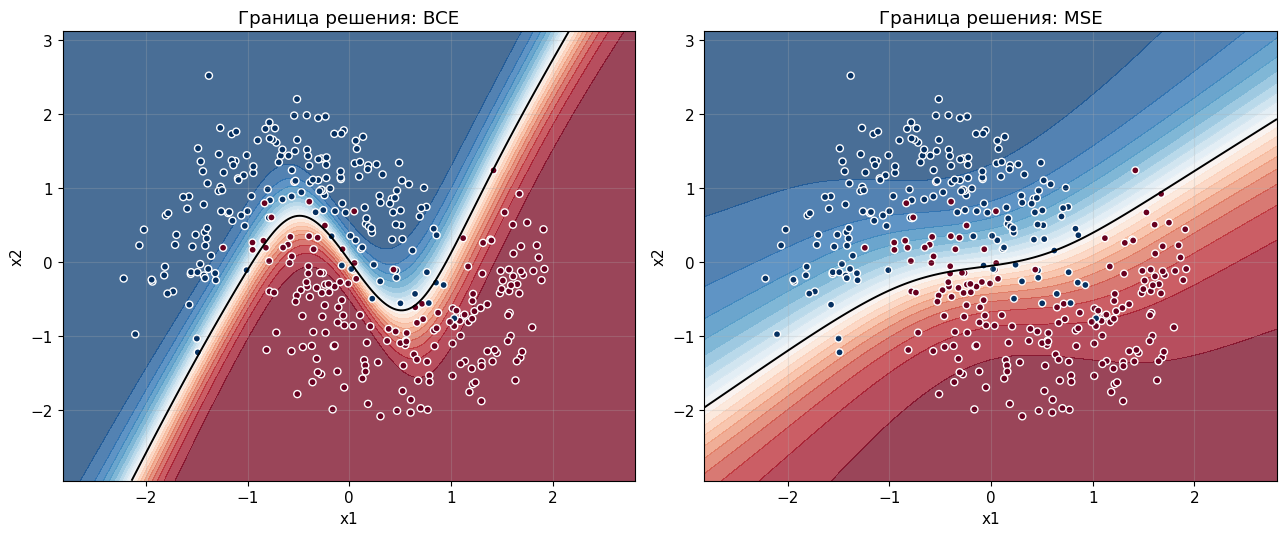

In [34]:
def plot_decision_boundaries(models):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_t = torch.tensor(grid, device=device)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    for ax, (loss_name, model) in zip(axes, models.items()):
        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(model(grid_t)).cpu().numpy().reshape(xx.shape)

        ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.75)
        ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=1.4)
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test.ravel(), cmap="RdBu_r", edgecolor="white", s=26)
        ax.set_title(f"Граница решения: {loss_name}")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/decision_boundaries_bce_vs_mse.png", dpi=160)
    plt.show()


plot_decision_boundaries(models)

## 5. Итоговая таблица

В таблице сравниваются финальные метрики на тестовой выборке.

`bce_metric` и `mse_metric` здесь считаются уже как метрики качества вероятностей, а не как обязательно оптимизируемая функция.

In [35]:
summary = pd.DataFrame(results).T
summary.index.name = "training_loss"
summary

,accuracy,f1,log_loss,brier_score
training_loss,,,,
BCE,0.944444,0.943503,0.149560,0.042632
MSE,0.891667,0.888889,0.296625,0.088968


## Вывод по базовому эксперименту

В базовом эксперименте при одинаковом `lr=0.05` перекрестная энтропия дает более сильный сигнал обратного распространения и быстрее выходит на высокие значения accuracy/F1. Это согласуется с формулой градиента: у BCE по логиту остается простой член $p-y$, а у MSE появляется дополнительный множитель $p(1-p)$.

Однако этот результат нельзя трактовать как универсальное доказательство, что MSE всегда хуже по итоговому качеству. Одинаковый learning rate не полностью честен к MSE, потому что масштаб ее градиентов меньше. Поэтому ниже добавлены множественные запуски, статистика и отдельная проверка с подбором learning rate на валидационной выборке.

## Связь с исходной статьей

В статье `project_base.pdf` функции потерь рассматриваются как критерии, которые оптимизируются во время обучения. Метрики используются для оценки качества после обучения. В этой работе идея проверена на задаче классификации. Одна и та же сеть обучается с разными loss-функциями. Затем сравниваются итоговые метрики и поведение градиентов при backpropagation.

## 6. Множественные запуски при фиксированном learning rate

Чтобы проверить устойчивость результата, повторим обучение 20 раз с разными начальными инициализациями. Данные, train/test split, архитектура и оптимизатор остаются одинаковыми. Здесь learning rate по-прежнему фиксирован: `lr=0.05` для обеих функций потерь.

In [ ]:
def train_with_seed(loss_name, seed, epochs=1000, lr=0.05, target_accuracy=0.90):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = BinaryMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    epoch_to_target = np.nan

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = loss_function(loss_name, logits, y_train_t)
        loss.backward()
        optimizer.step()

        if np.isnan(epoch_to_target) and (epoch % 10 == 0 or epoch == epochs - 1):
            if evaluate(model)["accuracy"] >= target_accuracy:
                epoch_to_target = epoch

    metrics = evaluate(model)
    metrics["epoch_to_accuracy_0.90"] = epoch_to_target
    return metrics


seeds = list(range(20))
fixed_lr_records = []

for loss_name in ["BCE", "MSE"]:
    for seed in seeds:
        metrics = train_with_seed(loss_name, seed, lr=0.05)
        fixed_lr_records.append({"loss": loss_name, "seed": seed, **metrics})

fixed_lr_df = pd.DataFrame(fixed_lr_records)
fixed_lr_df.head()

### Результаты множественных запусков

Ниже приведены среднее и стандартное отклонение по 20 запускам. Для `accuracy` и `f1` больше значит лучше, для `log_loss`, `brier_score` и `epoch_to_accuracy_0.90` меньше значит лучше.

In [ ]:
def summarize_runs(df):
    return (
        df.groupby("loss")[["accuracy", "f1", "log_loss", "brier_score", "epoch_to_accuracy_0.90"]]
        .agg(["mean", "std"])
        .round(4)
    )

fixed_lr_summary = summarize_runs(fixed_lr_df)
fixed_lr_summary

accuracy              f1         log_loss         brier_score          \
         mean     std    mean     std     mean     std        mean     std   
loss                                                                         
BCE    0.9487  0.0045  0.9482  0.0048   0.1363  0.0031      0.0381  0.0013   
MSE    0.9408  0.0144  0.9397  0.0150   0.1610  0.0351      0.0448  0.0118   

     epoch_to_accuracy_0.90           
                       mean      std  
loss                                  
BCE                184.5000  56.4265  
MSE                436.3158  92.6289

### Парное сравнение по seed

Так как для каждого seed обучаются обе модели, корректнее сравнивать не только средние значения, но и парные разности BCE против MSE на одном и том же seed.

In [ ]:
def paired_comparison(df):
    rows = []
    wide = df.pivot(index="seed", columns="loss")

    metric_specs = {
        "accuracy": "higher",
        "f1": "higher",
        "log_loss": "lower",
        "brier_score": "lower",
        "epoch_to_accuracy_0.90": "lower",
    }

    for metric, direction in metric_specs.items():
        bce = wide[metric]["BCE"]
        mse = wide[metric]["MSE"]
        advantage = bce - mse if direction == "higher" else mse - bce
        t_stat, p_value = stats.ttest_rel(bce, mse, nan_policy="omit")
        rows.append({
            "metric": metric,
            "better_direction": direction,
            "mean_BCE_advantage": advantage.mean(),
            "std_advantage": advantage.std(),
            "BCE_wins": int((advantage > 0).sum()),
            "ties": int((advantage == 0).sum()),
            "p_value_paired_ttest": p_value,
        })

    return pd.DataFrame(rows).round(5)


paired_fixed_lr = paired_comparison(fixed_lr_df)
paired_fixed_lr

,metric,better_direction,mean_BCE_advantage,std_advantage,BCE_wins,ties,p_value_paired_ttest
0,accuracy,higher,0.00792,0.01322,17,1,0.01490
1,f1,higher,0.00855,0.01376,17,0,0.01196
2,log_loss,lower,0.02476,0.03390,20,0,0.00407
3,brier_score,lower,0.00674,0.01131,20,0,0.01533
4,epoch_to_accuracy_0.90,lower,262.10526,60.33047,19,0,0.00000


## 7. Проверка честности сравнения: подбор learning rate

Одинаковый `lr=0.05` показывает различие в масштабе градиентов, но не является полностью честным способом сравнить итоговое качество моделей. Поэтому дополнительно делаем небольшой sweep по learning rate. Learning rate выбирается по validation split, а test остается отложенным для финальной проверки.

In [ ]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train
)

X_fit_t = torch.tensor(X_fit, device=device)
y_fit_t = torch.tensor(y_fit, device=device)
X_val_t = torch.tensor(X_val, device=device)


def train_on_split(loss_name, lr, seed, epochs, X_fit_t, y_fit_t):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = BinaryMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_fit_t)
        loss = loss_function(loss_name, logits, y_fit_t)
        loss.backward()
        optimizer.step()

    return model


lr_grid = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
lr_records = []

for loss_name in ["BCE", "MSE"]:
    for lr in lr_grid:
        for seed in range(5):
            model = train_on_split(loss_name, lr, seed, epochs=500, X_fit_t=X_fit_t, y_fit_t=y_fit_t)
            metrics = evaluate(model, X_val_t, y_val)
            lr_records.append({"loss": loss_name, "lr": lr, "seed": seed, **metrics})

lr_df = pd.DataFrame(lr_records)
lr_summary = (
    lr_df.groupby(["loss", "lr"])[["accuracy", "f1", "log_loss", "brier_score"]]
    .agg(["mean", "std"])
    .round(4)
)
lr_summary

accuracy              f1         log_loss         brier_score  \
               mean     std    mean     std     mean     std        mean   
loss lr                                                                    
BCE  0.005   0.8695  0.0026  0.8666  0.0023   0.3163  0.0022      0.0964   
     0.010   0.8743  0.0072  0.8709  0.0065   0.3028  0.0076      0.0919   
     0.020   0.9152  0.0071  0.9151  0.0077   0.2058  0.0270      0.0600   
     0.050   0.9286  0.0067  0.9292  0.0066   0.1678  0.0080      0.0507   
     0.100   0.9314  0.0043  0.9318  0.0043   0.1584  0.0094      0.0479   
     0.200   0.9343  0.0021  0.9350  0.0022   0.1660  0.0136      0.0475   
     0.500   0.9352  0.0043  0.9361  0.0048   0.1844  0.0172      0.0482   
     1.000   0.9229  0.0071  0.9239  0.0070   0.2028  0.0181      0.0519   
MSE  0.005   0.8629  0.0103  0.8608  0.0090   0.3320  0.0050      0.1000   
     0.010   0.8695  0.0026  0.8666  0.0023   0.3228  0.0024      0.0977   
     0.020   0.8695  0.0026  0.8666  0.0023   0.3164  0.0036      0.0956   
     0.050   0.9114  0.0064  0.9099  0.0069   0.2350  0.0216      0.0656   
     0.100   0.9257  0.0026  0.9265  0.0028   0.1815  0.0061      0.0542   
     0.200   0.9286  0.0048  0.9292  0.0047   0.1728  0.0076      0.0517   
     0.500   0.9343  0.0021  0.9348  0.0020   0.1673  0.0059      0.0490   
     1.000   0.9333  0.0034  0.9340  0.0036   0.1685  0.0059      0.0493   

                    
               std  
loss lr             
BCE  0.005  0.0011  
     0.010  0.0031  
     0.020  0.0084  
     0.050  0.0023  
     0.100  0.0025  
     0.200  0.0017  
     0.500  0.0013  
     1.000  0.0020  
MSE  0.005  0.0017  
     0.010  0.0011  
     0.020  0.0016  
     0.050  0.0074  
     0.100  0.0018  
     0.200  0.0027  
     0.500  0.0012  
     1.000  0.0009

In [ ]:
lr_choice_table = (
    lr_df.groupby(["loss", "lr"])[["accuracy", "f1", "log_loss", "brier_score"]]
    .mean()
    .reset_index()
    .sort_values(["loss", "accuracy", "f1", "log_loss"], ascending=[True, False, False, True])
)

best_lr_by_loss = lr_choice_table.groupby("loss").head(1).set_index("loss")["lr"].to_dict()
lr_choice_table.groupby("loss").head(3).round(4)

,loss,lr,accuracy,f1,log_loss,brier_score
6,BCE,0.5,0.9352,0.9361,0.1844,0.0482
5,BCE,0.2,0.9343,0.9350,0.1660,0.0475
4,BCE,0.1,0.9314,0.9318,0.1584,0.0479
14,MSE,0.5,0.9343,0.9348,0.1673,0.0490
15,MSE,1.0,0.9333,0.9340,0.1685,0.0493
13,MSE,0.2,0.9286,0.9292,0.1728,0.0517


## 8. Финальное сравнение с подобранным learning rate

Теперь обучим модели на исходной train-выборке и оценим на test, но для каждой функции потерь используем learning rate, выбранный по validation. Это проверяет, остается ли преимущество BCE после более честной настройки масштаба шага.

In [ ]:
tuned_records = []

for loss_name in ["BCE", "MSE"]:
    chosen_lr = best_lr_by_loss[loss_name]
    for seed in seeds:
        metrics = train_with_seed(loss_name, seed, epochs=1000, lr=chosen_lr)
        tuned_records.append({"loss": loss_name, "seed": seed, "lr": chosen_lr, **metrics})

tuned_df = pd.DataFrame(tuned_records)
summarize_runs(tuned_df)

accuracy              f1         log_loss         brier_score          \
         mean     std    mean     std     mean     std        mean     std   
loss                                                                         
BCE    0.9482  0.0042  0.9473  0.0043   0.1808  0.0108      0.0431  0.0024   
MSE    0.9474  0.0044  0.9467  0.0046   0.1379  0.0013      0.0378  0.0004   

     epoch_to_accuracy_0.90           
                       mean      std  
loss                                  
BCE                    33.0  10.3110  
MSE                    62.0  17.3509

In [ ]:
paired_tuned = paired_comparison(tuned_df)
paired_tuned

,metric,better_direction,mean_BCE_advantage,std_advantage,BCE_wins,ties,p_value_paired_ttest
0,accuracy,higher,0.00083,0.00681,8,4,0.59058
1,f1,higher,0.00063,0.00714,9,0,0.69669
2,log_loss,lower,-0.04290,0.01016,0,0,0.00000
3,brier_score,lower,-0.00529,0.00229,0,0,0.00000
4,epoch_to_accuracy_0.90,lower,29.00000,9.67906,20,0,0.00000


## Итоговый вывод

Теоретическая часть подтверждается: BCE дает более прямой и сильный градиент по логиту, поэтому при одинаковом `lr` быстрее выходит на хорошее качество. Это видно по графикам градиентов, скорости достижения accuracy 0.90 и множественным запускам при `lr=0.05`.

После подбора learning rate вывод становится аккуратнее. MSE почти догоняет BCE по финальным `accuracy` и `f1`, а в данном запуске с выбранным по validation accuracy learning rate даже получает меньшие `log_loss` и `brier_score` на test. При этом BCE все равно достигает порога accuracy 0.90 быстрее.

Поэтому корректная формулировка такая: для бинарной классификации BCE является более естественной и численно устойчивой функцией потерь, особенно при работе с логитами. MSE хуже согласована с backpropagation через sigmoid и требует более осторожной настройки шага, но при удачном learning rate тоже может обучить классификатор до сопоставимого итогового качества.